# Chapter 08: More Single View Geometry

Source orientation: printed pages 195-236; PDF pages 213-254.

This notebook is a standalone computational pass through the chapter. It uses synthetic geometry rather than textbook figures so every construction has known ground truth, executable checks, and reproducible artifacts under `artifacts/chapter-08`.


## Chapter Goal

The chapter's central move is to treat a single perspective image as a projective measuring device. The camera center sends planes to homographies, space directions to vanishing points, scene planes to vanishing lines, and the plane at infinity to calibration constraints. Once the image of the absolute conic (IAC) is known or constrained, angles and metric rectifications become computable from a single view.

By the end of the notebook you should be able to inspect a single synthetic image and recover these pieces: a horizon from two vanishing points, internal calibration from an orthogonal vanishing triad, a height ratio from a ground-plane horizon plus a vertical vanishing point, and an apparent conic from a projected quadric.


## Translation Guide

| Book object | Computational representation in this notebook | What to inspect |
| --- | --- | --- |
| Camera with fixed center | matrices `P1`, `P2`, `H_same = K R K^{-1}` | same ray at different depths remains coincident under pure rotation |
| Plane at infinity `pi_infinity` | homogeneous directions `d` with image `v = K R d` | parallel 3D lines meet at a common vanishing point |
| Vanishing line of a plane | line through two vanishing points, or `l = K^{-T} n` | all vanishing points for directions in the plane lie on that line |
| IAC `omega` | symmetric matrix `omega = K^{-T} K^{-1}` | orthogonal directions satisfy `v_i^T omega v_j = 0` |
| DIAC `omega_star` | `K K^T` | plane-angle and point-line orthogonality checks |
| Affine single-view measurement | 1D projective rectification of an imaged vertical line | the vanishing point is mapped to infinity before ratios are read |
| Quadric apparent contour | dual conic `C_star = P Q_star P^T` and sampled contour generator | projected contour-generator points lie on the image conic |
| Calibrating conic | `K^{-T} diag(1,1,-1) K^{-1}` | its center and radius/skew encode the internal calibration |


## Library Routing

| Concept | Representation | Library | Why this route | Check |
| --- | --- | --- | --- | --- |
| Same-center images and parallax | paired projections of near/far points on common rays | `NumPy`, `Matplotlib` | a 2D residual plot makes the no-parallax invariant visible | homography residual near zero; translated-center parallax positive |
| Vanishing points and horizon | Manhattan line families projected from 3D | `NumPy`, `Matplotlib` | homogeneous line incidence is the core construction, and static labels are readable | each projected line is incident with its family vanishing point |
| IAC calibration from orthogonal directions | SVD nullspace solve for square-pixel `omega` plus orthocenter geometry | `NumPy`, `SymPy`, `Matplotlib` | linear constraints and the geometric orthocenter can be compared directly | recovered principal point and focal length match ground truth |
| Height transfer and affine metrology | Criminisi-style transfer construction and 1D projective rectification | `NumPy`, `Matplotlib` | the construction is projective incidence, so a labeled 2D diagram is the cleanest view | recovered height ratio equals the known synthetic ratio |
| Apparent contour of a quadric | contour generator circle, dual projected conic, and 3D inspection scene | `NumPy`, `Plotly`, `Matplotlib` | Plotly exposes the 3D tangent geometry; Matplotlib shows the image conic and calibration conic | contour samples satisfy `x^T C x = 0` |
| Noise sensitivity lab | perturb vanishing points and endpoint measurements | `NumPy`, `Matplotlib` | error curves are more useful than a single lucky reconstruction | median errors stay finite and increase with noise |

The catalog routes projective camera chapters through homogeneous linear algebra and image-geometry checks. Matplotlib is used for durable incidence diagrams; Plotly is used where the 3D quadric, camera rays, and contour generator need rotation and depth inspection.


## Route Through The Chapter

1. Start with the camera center: pure image-plane motion gives a homography and no parallax; moving the center reveals depth.
2. Build vanishing points and a vanishing line from projected Manhattan directions.
3. Turn orthogonal vanishing directions into linear constraints on the IAC and read calibration from the result.
4. Use the horizon plus vertical vanishing point to transfer a known height to another vertical segment.
5. Connect conics and quadrics: a conic back-projects to a cone, and a quadric projects to an apparent conic.
6. Close with a noise lab and sanity checks that validate the visual artifacts and the projective identities.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import sympy as sp

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.cameras import camera_matrix, look_at_rotation, project_points

TOPIC = "chapter-08"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "interactive"
CHECK_DIR = ARTIFACT_ROOT / "checks"
for folder in [FIG_DIR, HTML_DIR, CHECK_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(808)
artifact_paths = []
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})


In [2]:
def as_hpoint(xy):
    xy = np.asarray(xy, dtype=float)
    return np.array([xy[0], xy[1], 1.0], dtype=float)


def finite_xy(xh, *, eps=1e-12):
    xh = np.asarray(xh, dtype=float)
    if abs(xh[-1]) < eps:
        raise ValueError("point is at infinity")
    return xh[:2] / xh[-1]


def normalize_finite(xh):
    xh = np.asarray(xh, dtype=float)
    return xh / xh[-1]


def normalize_line(line):
    line = np.asarray(line, dtype=float)
    scale = np.linalg.norm(line[:2])
    return line / scale if scale > 1e-12 else line


def line_from_points(p, q):
    return normalize_line(np.cross(np.asarray(p, dtype=float), np.asarray(q, dtype=float)))


def intersect_lines(l1, l2):
    return np.cross(np.asarray(l1, dtype=float), np.asarray(l2, dtype=float))


def rotation_x(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[1.0, 0.0, 0.0], [0.0, c, -s], [0.0, s, c]])


def rotation_y(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]])


def project_homogeneous(P, Xh):
    Xh = np.asarray(Xh, dtype=float)
    return (np.asarray(P, dtype=float) @ Xh.T).T


def dehomogeneous_rows(xh):
    xh = np.asarray(xh, dtype=float)
    return xh[:, :2] / xh[:, 2:]


def draw_image_box(ax, width=1280, height=760, **kwargs):
    style = {"fill": False, "edgecolor": "#222222", "linewidth": 1.0, "linestyle": "--"}
    style.update(kwargs)
    rect = plt.Rectangle((0, 0), width, height, **style)
    ax.add_patch(rect)
    ax.text(12, 28, "nominal image", color=style["edgecolor"], fontsize=8)


def draw_hline(ax, line, xlim, ylim, **kwargs):
    line = np.asarray(line, dtype=float)
    a, b, c = line
    points = []
    for x in xlim:
        if abs(b) > 1e-12:
            y = -(a * x + c) / b
            if min(ylim) - 1e-9 <= y <= max(ylim) + 1e-9:
                points.append((x, y))
    for y in ylim:
        if abs(a) > 1e-12:
            x = -(b * y + c) / a
            if min(xlim) - 1e-9 <= x <= max(xlim) + 1e-9:
                points.append((x, y))
    if len(points) >= 2:
        p0, p1 = points[0], points[-1]
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], **kwargs)


def altitude_from_vertex_to_side(vertex_xy, side_line):
    a, b, _ = side_line
    x, y = vertex_xy
    return normalize_line(np.array([-b, a, b * x - a * y], dtype=float))


def orthocenter_of_triangle(points_xy):
    p0, p1, p2 = [np.asarray(p, dtype=float) for p in points_xy]
    side12 = line_from_points(as_hpoint(p1), as_hpoint(p2))
    side02 = line_from_points(as_hpoint(p0), as_hpoint(p2))
    alt0 = altitude_from_vertex_to_side(p0, side12)
    alt1 = altitude_from_vertex_to_side(p1, side02)
    return finite_xy(intersect_lines(alt0, alt1)), (alt0, alt1, side12, side02)


def square_pixel_omega_from_vps(vps):
    rows = []
    for i, j in [(0, 1), (0, 2), (1, 2)]:
        u = np.asarray(vps[i], dtype=float)
        v = np.asarray(vps[j], dtype=float)
        rows.append([
            u[0] * v[0] + u[1] * v[1],
            u[0] * v[2] + u[2] * v[0],
            u[1] * v[2] + u[2] * v[1],
            u[2] * v[2],
        ])
    A = np.asarray(rows, dtype=float)
    _, _, vt = np.linalg.svd(A)
    w = vt[-1]
    if w[0] < 0:
        w = -w
    omega = np.array([[w[0], 0.0, w[1]], [0.0, w[0], w[2]], [w[1], w[2], w[3]]], dtype=float)
    return omega, A


def square_pixel_K_from_omega(omega):
    w1 = omega[0, 0]
    cx = -omega[0, 2] / w1
    cy = -omega[1, 2] / w1
    f2 = omega[2, 2] / w1 - cx * cx - cy * cy
    if f2 <= 0:
        raise ValueError("omega does not define a real square-pixel focal length")
    f = math.sqrt(f2)
    return np.array([[f, 0.0, cx], [0.0, f, cy], [0.0, 0.0, 1.0]])


def conic_value(C, xh):
    xh = np.asarray(xh, dtype=float)
    return float(xh.T @ C @ xh)


## 1. Camera Center: Homography Versus Parallax

The chapter separates image-plane motion from camera-center motion. If the center is fixed, every 3D ray keeps its identity and two points at different depths on that ray remain coincident after a pure rotation. If the center moves, the near and far points split. That split is motion parallax and it is the first signal that image correspondences depend on scene depth.


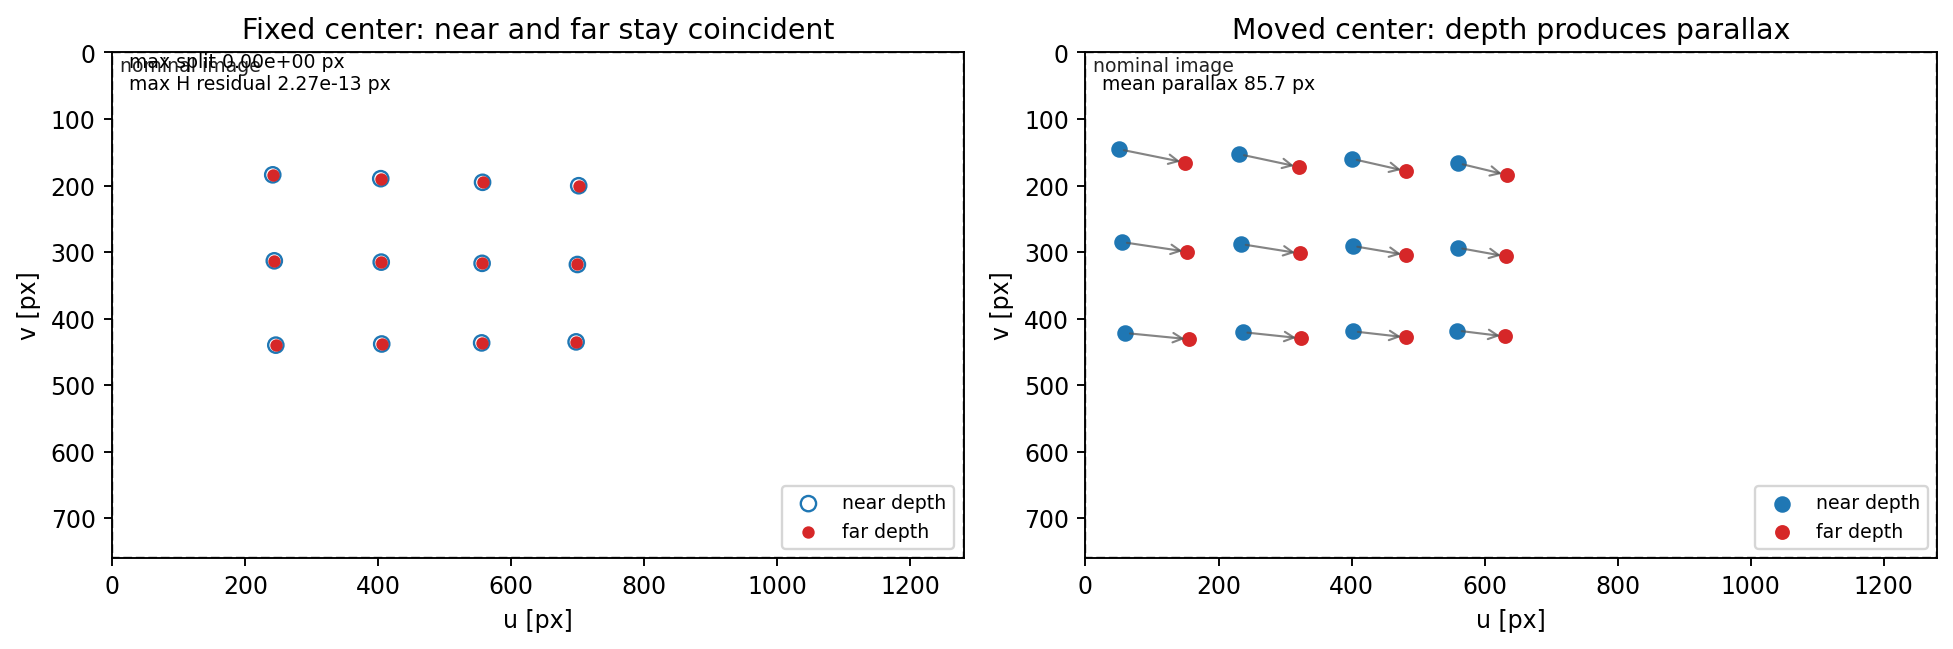

same-center homography residual: 2.274e-13 px
mean moved-center parallax: 85.71 px


In [3]:
K = np.array([[900.0, 0.0, 640.0], [0.0, 900.0, 380.0], [0.0, 0.0, 1.0]])
image_size = (1280, 760)
R_pure = rotation_y(np.deg2rad(-10.0)) @ rotation_x(np.deg2rad(4.0))
P1 = K @ np.hstack([np.eye(3), np.zeros((3, 1))])
P2_same_center = K @ np.hstack([R_pure, np.zeros((3, 1))])
C_moved = np.array([0.65, 0.10, 0.15])
P2_moved_center = K @ np.hstack([R_pure, -R_pure @ C_moved.reshape(3, 1)])
H_same = K @ R_pure @ np.linalg.inv(K)

world_points = []
for u in np.linspace(420.0, 860.0, 4):
    for v in np.linspace(260.0, 500.0, 3):
        x = np.array([u, v, 1.0])
        direction = np.linalg.inv(K) @ x
        for depth in [4.0, 8.0]:
            world_points.append(depth * direction)
world_points = np.asarray(world_points)
Xh = np.c_[world_points, np.ones(len(world_points))]

x1_h = project_homogeneous(P1, Xh)
x2_same_h = project_homogeneous(P2_same_center, Xh)
x2_moved_h = project_homogeneous(P2_moved_center, Xh)
x2_same = dehomogeneous_rows(x2_same_h)
x2_moved = dehomogeneous_rows(x2_moved_h)
Hx1 = dehomogeneous_rows((H_same @ x1_h.T).T)

pairs = np.arange(len(world_points)).reshape(-1, 2)
same_center_pair_splits = np.array([np.linalg.norm(x2_same[i] - x2_same[j]) for i, j in pairs])
moved_center_pair_splits = np.array([np.linalg.norm(x2_moved[i] - x2_moved[j]) for i, j in pairs])
same_center_homography_residual = float(np.max(np.linalg.norm(Hx1 - x2_same, axis=1)))
mean_translation_parallax = float(np.mean(moved_center_pair_splits))

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.8))
for ax in axes:
    draw_image_box(ax, *image_size)
    ax.set_xlim(0, image_size[0])
    ax.set_ylim(image_size[1], 0)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("u [px]")
    ax.set_ylabel("v [px]")

axes[0].set_title("Fixed center: near and far stay coincident")
axes[0].scatter(x2_same[0::2, 0], x2_same[0::2, 1], s=42, facecolors="none", edgecolors="#1f77b4", label="near depth")
axes[0].scatter(x2_same[1::2, 0], x2_same[1::2, 1], s=18, color="#d62728", label="far depth")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].text(25, 55, f"max split {same_center_pair_splits.max():.2e} px/nmax H residual {same_center_homography_residual:.2e} px", fontsize=8)

axes[1].set_title("Moved center: depth produces parallax")
axes[1].scatter(x2_moved[0::2, 0], x2_moved[0::2, 1], s=36, color="#1f77b4", label="near depth")
axes[1].scatter(x2_moved[1::2, 0], x2_moved[1::2, 1], s=28, color="#d62728", label="far depth")
for i, j in pairs:
    axes[1].annotate("", xy=x2_moved[j], xytext=x2_moved[i], arrowprops={"arrowstyle": "->", "color": "#555555", "lw": 0.9, "alpha": 0.72})
axes[1].legend(loc="lower right", fontsize=8)
axes[1].text(25, 55, f"mean parallax {mean_translation_parallax:.1f} px", fontsize=8)
fig.tight_layout()

center_path = save_matplotlib(fig, TOPIC, "figures", "same-center-homography-vs-parallax.png", dpi=170)
plt.close(fig)
artifact_paths.append(center_path)
display_artifact(center_path, width=920)

print(f"same-center homography residual: {same_center_homography_residual:.3e} px")
print(f"mean moved-center parallax: {mean_translation_parallax:.2f} px")


## 2. Vanishing Points And The Horizon

A vanishing point is the image of a direction. In homogeneous coordinates, a direction `d` is a point on the plane at infinity, and its image is `v = K R d`. A scene plane's vanishing line is the image of the line where that plane meets the plane at infinity. For the ground plane below, the horizon is the line through the two ground-direction vanishing points.


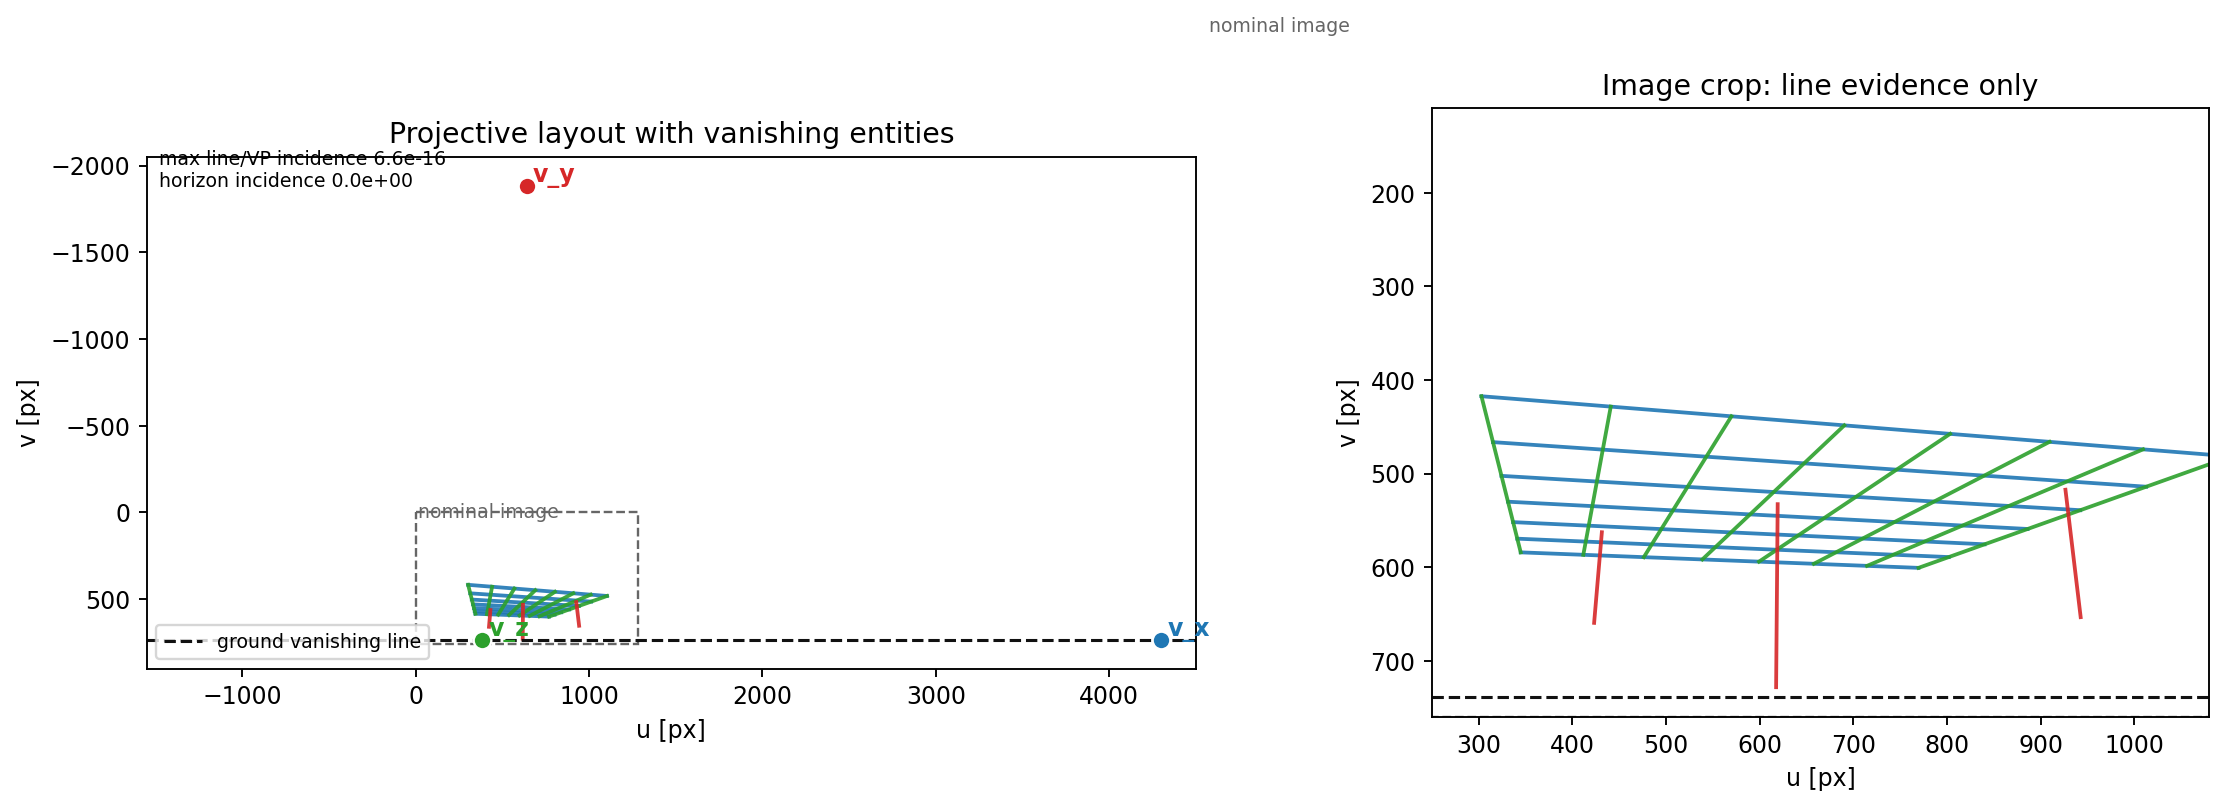

In [4]:
scene_center = np.array([3.2, 2.2, -6.2])
scene_rotation = look_at_rotation(scene_center, target=np.array([0.5, -2.0, 4.0]), up=np.array([0.0, 1.0, 0.0]))
P_scene = camera_matrix(K, scene_rotation, scene_center)

directions = {
    "ground x": np.array([1.0, 0.0, 0.0]),
    "ground z": np.array([0.0, 0.0, 1.0]),
    "vertical": np.array([0.0, 1.0, 0.0]),
}
vanishing_points = {name: K @ (scene_rotation @ direction) for name, direction in directions.items()}
vx, vz, vvertical = vanishing_points["ground x"], vanishing_points["ground z"], vanishing_points["vertical"]
ground_horizon = normalize_line(np.cross(vx, vz))

segments = []
segment_families = []
for z in np.linspace(0.5, 8.5, 7):
    segments.append((np.array([-3.0, 0.0, z]), np.array([4.0, 0.0, z])))
    segment_families.append("ground x")
for x in np.linspace(-3.0, 4.0, 8):
    segments.append((np.array([x, 0.0, 0.5]), np.array([x, 0.0, 8.5])))
    segment_families.append("ground z")
vertical_posts = [(-2.2, 1.4, 2.2), (0.8, 2.1, 3.8), (2.8, 1.25, 6.3)]
for x, height, z in vertical_posts:
    segments.append((np.array([x, 0.0, z]), np.array([x, height, z])))
    segment_families.append("vertical")

projected_segments = []
incidence_errors = []
for (a, b), family in zip(segments, segment_families):
    xy = project_points(P_scene, np.vstack([a, b]))
    ah, bh = as_hpoint(xy[0]), as_hpoint(xy[1])
    line = line_from_points(ah, bh)
    v = vanishing_points[family]
    incidence_errors.append(abs(line @ v) / max(1.0, np.linalg.norm(v)))
    projected_segments.append((xy[0], xy[1], family, line))
max_vanishing_incidence = float(np.max(incidence_errors))
horizon_incidence = float(abs(ground_horizon @ vx) + abs(ground_horizon @ vz))

full_xlim = (-1550, 4500)
full_ylim = (900, -2050)
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.3), gridspec_kw={"width_ratios": [1.35, 1.0]})
colors = {"ground x": "#1f77b4", "ground z": "#2ca02c", "vertical": "#d62728"}
for ax, xlim, ylim, title in [
    (axes[0], full_xlim, full_ylim, "Projective layout with vanishing entities"),
    (axes[1], (250, 1080), (760, 110), "Image crop: line evidence only"),
]:
    for p, q, family, _ in projected_segments:
        ax.plot([p[0], q[0]], [p[1], q[1]], color=colors[family], linewidth=1.6, alpha=0.9)
    draw_hline(ax, ground_horizon, xlim, ylim, color="#111111", linewidth=1.3, linestyle="--", label="ground vanishing line")
    draw_image_box(ax, *image_size, edgecolor="#666666")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel("u [px]")
    ax.set_ylabel("v [px]")

for label, v, color in [("v_x", vx, colors["ground x"]), ("v_z", vz, colors["ground z"]), ("v_y", vvertical, colors["vertical"])]:
    xy = finite_xy(v)
    axes[0].scatter([xy[0]], [xy[1]], s=56, color=color, edgecolor="white", zorder=5)
    axes[0].text(xy[0] + 35, xy[1] - 25, label, color=color, weight="bold")
axes[0].legend(loc="lower left", fontsize=8)
axes[0].text(-1480, -1880, f"max line/VP incidence {max_vanishing_incidence:.1e}/nhorizon incidence {horizon_incidence:.1e}", fontsize=8)
fig.tight_layout()

vanishing_path = save_matplotlib(fig, TOPIC, "figures", "manhattan-vanishing-points-and-horizon.png", dpi=170)
plt.close(fig)
artifact_paths.append(vanishing_path)
display_artifact(vanishing_path, width=940)


## 3. The Image Of The Absolute Conic

Calibration converts an image point into a ray direction: `d = K^{-1} x`. The matrix `omega = K^{-T} K^{-1}` packages this relation so angles can be read from homogeneous image coordinates. In particular, orthogonal scene directions with vanishing points `v_i` and `v_j` satisfy `v_i^T omega v_j = 0`.

The next cell also includes a small symbolic check: rotating the camera changes the homography from the plane at infinity to the image, but it cancels out of the IAC.


In [5]:
fx, fy, theta = sp.symbols("fx fy theta", positive=True)
K_sym = sp.diag(fx, fy, 1)
Rz_sym = sp.Matrix([[sp.cos(theta), -sp.sin(theta), 0], [sp.sin(theta), sp.cos(theta), 0], [0, 0, 1]])
omega_from_rotated_plane_at_infinity = (K_sym * Rz_sym).inv().T * (K_sym * Rz_sym).inv()
omega_without_rotation = K_sym.inv().T * K_sym.inv()
assert sp.simplify(omega_from_rotated_plane_at_infinity - omega_without_rotation) == sp.zeros(3)


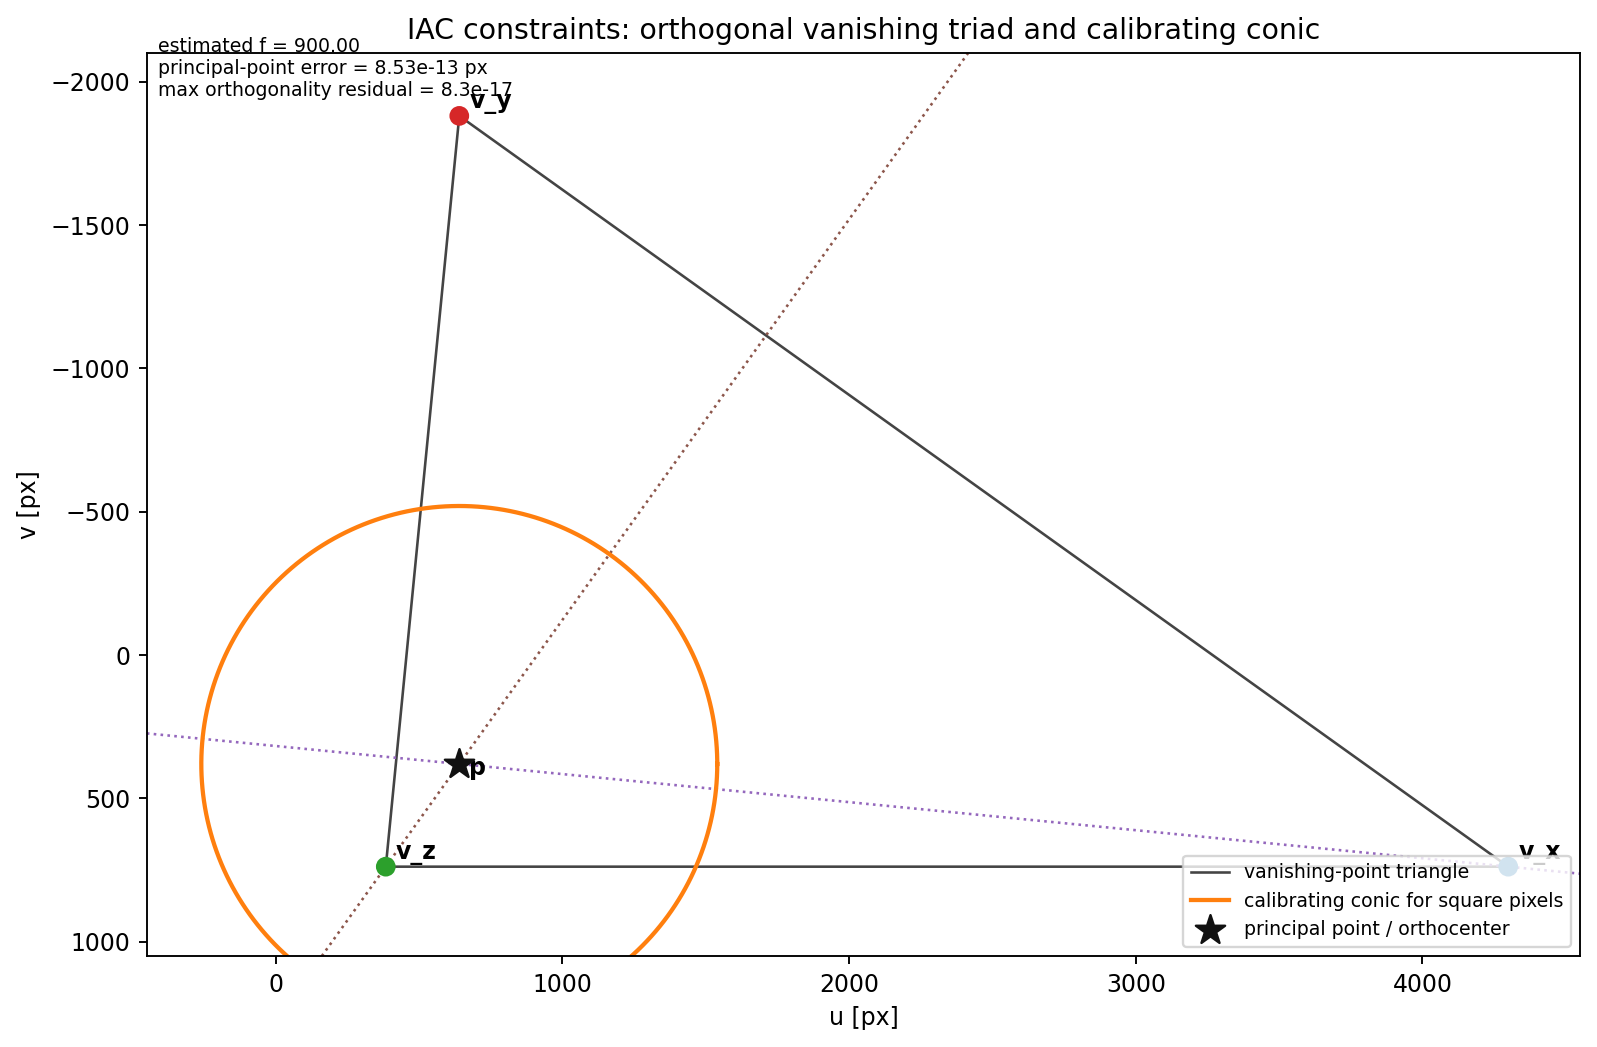

K estimated from three orthogonal vanishing points:
[[900.   0. 640.]
 [  0. 900. 380.]
 [  0.   0.   1.]]


In [6]:
omega_true = np.linalg.inv(K @ K.T)
omega_star_true = K @ K.T
vps = [vx, vz, vvertical]
vp_xy = [finite_xy(v) for v in vps]
omega_est_h, omega_constraint_matrix = square_pixel_omega_from_vps(vps)
K_est = square_pixel_K_from_omega(omega_est_h)

omega_scale = float(np.sum(omega_est_h * omega_true) / np.sum(omega_est_h * omega_est_h))
omega_est = omega_scale * omega_est_h
orthogonality_residuals = []
for i, j in [(0, 1), (0, 2), (1, 2)]:
    numerator = abs(vps[i].T @ omega_true @ vps[j])
    denominator = math.sqrt(abs(vps[i].T @ omega_true @ vps[i]) * abs(vps[j].T @ omega_true @ vps[j]))
    orthogonality_residuals.append(float(numerator / denominator))
max_iac_orthogonality_residual = float(np.max(orthogonality_residuals))
principal_point_est = K_est[:2, 2]
focal_est = float(K_est[0, 0])
principal_point_error = float(np.linalg.norm(principal_point_est - K[:2, 2]))
focal_error = float(abs(focal_est - K[0, 0]))

orthocenter_xy, altitude_data = orthocenter_of_triangle(vp_xy)
orthocenter_error = float(np.linalg.norm(orthocenter_xy - K[:2, 2]))
calibrating_center = principal_point_est
calibrating_radius = focal_est

fig, ax = plt.subplots(figsize=(9.5, 6.2))
triangle = np.vstack([vp_xy, vp_xy[0]])
ax.plot(triangle[:, 0], triangle[:, 1], color="#444444", linewidth=1.1, label="vanishing-point triangle")
ax.scatter([p[0] for p in vp_xy], [p[1] for p in vp_xy], s=54, color=["#1f77b4", "#2ca02c", "#d62728"], zorder=4)
for label, p in zip(["v_x", "v_z", "v_y"], vp_xy):
    ax.text(p[0] + 35, p[1] - 28, label, weight="bold")

alt0, alt1, side12, side02 = altitude_data
for alt, color in [(alt0, "#9467bd"), (alt1, "#8c564b")]:
    draw_hline(ax, alt, (-450, 4550), (1050, -2100), color=color, linewidth=1.1, linestyle=":")

circle_t = np.linspace(0, 2 * np.pi, 500)
cal_x = calibrating_center[0] + calibrating_radius * np.cos(circle_t)
cal_y = calibrating_center[1] + calibrating_radius * np.sin(circle_t)
ax.plot(cal_x, cal_y, color="#ff7f0e", linewidth=1.8, label="calibrating conic for square pixels")
ax.scatter([K[0, 2]], [K[1, 2]], marker="*", s=170, color="#111111", label="principal point / orthocenter", zorder=5)
ax.text(K[0, 2] + 35, K[1, 2] + 40, "p", weight="bold")
ax.set_xlim(-450, 4550)
ax.set_ylim(1050, -2100)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("u [px]")
ax.set_ylabel("v [px]")
ax.set_title("IAC constraints: orthogonal vanishing triad and calibrating conic")
ax.legend(loc="lower right", fontsize=8)
ax.text(-410, -1950, f"estimated f = {focal_est:.2f}/nprincipal-point error = {principal_point_error:.2e} px/nmax orthogonality residual = {max_iac_orthogonality_residual:.1e}", fontsize=8)
fig.tight_layout()

iac_path = save_matplotlib(fig, TOPIC, "figures", "iac-orthogonal-triad-calibrating-conic.png", dpi=170)
plt.close(fig)
artifact_paths.append(iac_path)
display_artifact(iac_path, width=860)

print("K estimated from three orthogonal vanishing points:")
print(np.round(K_est, 6))


## 4. Single-View Height Transfer

Affine 3D measurement needs a vanishing line for a reference plane and a vanishing point for a direction not parallel to that plane. In the ground-plane version, the horizon gives the ground vanishing line and the vertical vanishing point gives the direction in which heights are measured.

The construction below transfers the known height at `B1` to the vertical line through `B2`, then rectifies that imaged vertical line by sending the vertical vanishing point to infinity. This is the projective core behind single-view height metrology and the height-transfer homology used in architectural measurements.


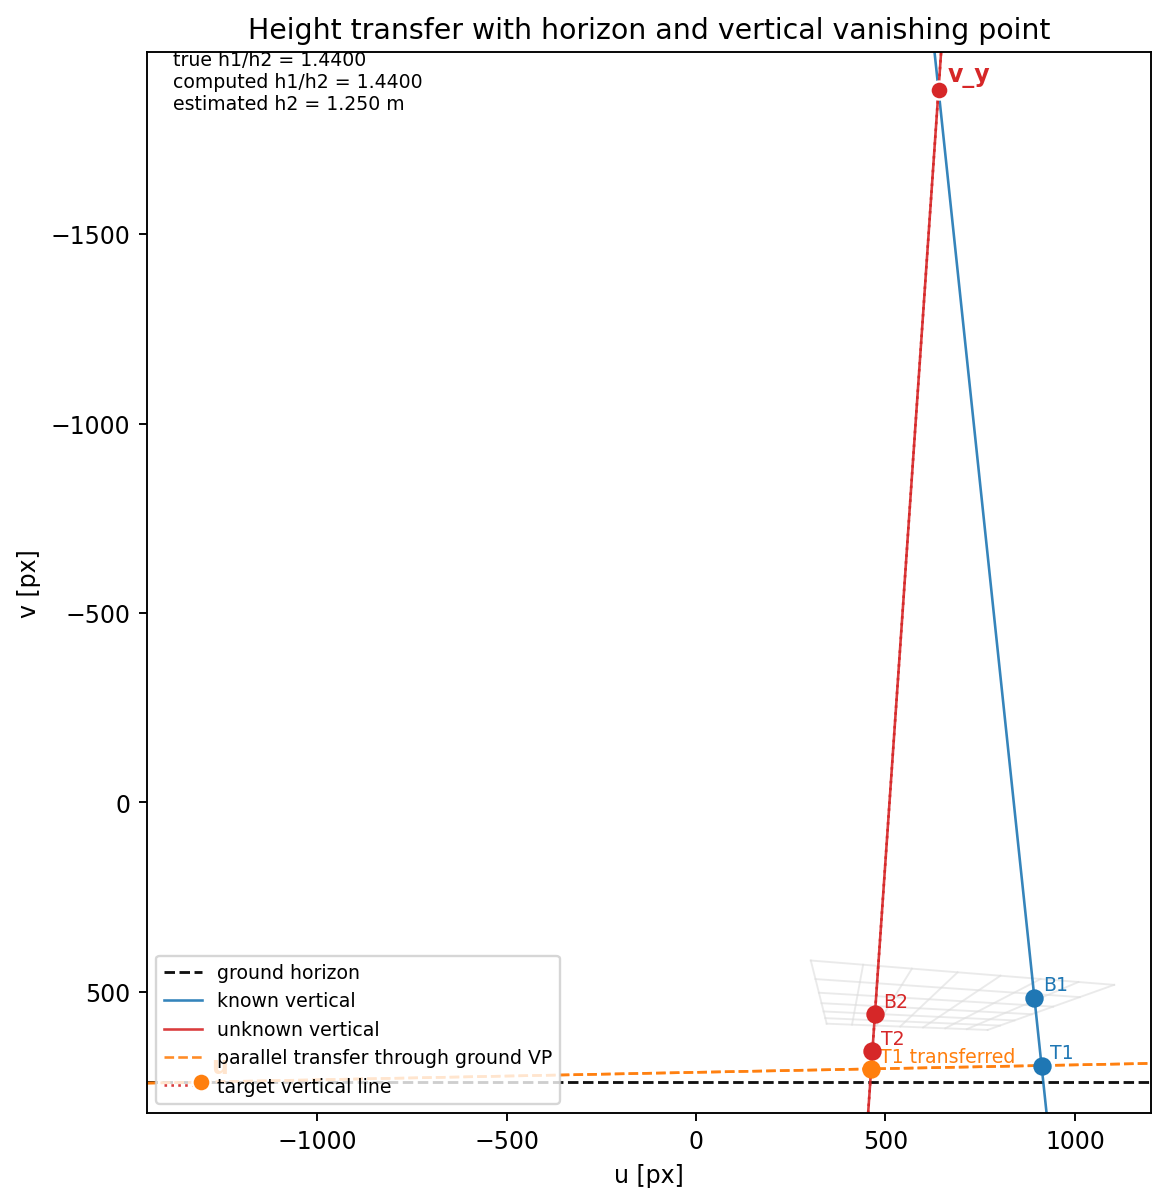

In [7]:
B1 = np.array([-1.8, 0.0, 2.2])
height_1 = 1.80
T1 = B1 + np.array([0.0, height_1, 0.0])
B2 = np.array([2.3, 0.0, 5.8])
height_2_true = 1.25
T2 = B2 + np.array([0.0, height_2_true, 0.0])
height_points = project_points(P_scene, np.vstack([B1, T1, B2, T2]))
b1, t1, b2, t2 = [as_hpoint(p) for p in height_points]

u_ground = normalize_finite(intersect_lines(line_from_points(b1, b2), ground_horizon))
vertical_line_2 = line_from_points(vvertical, b2)
ttilde1 = normalize_finite(intersect_lines(line_from_points(t1, u_ground), vertical_line_2))


def coordinate_on_line_from_base(point, base, vanishing):
    base_xy = finite_xy(base)
    vanishing_xy = finite_xy(vanishing)
    direction = vanishing_xy - base_xy
    direction = direction / np.linalg.norm(direction)
    return float((finite_xy(point) - base_xy) @ direction)


ttilde_coord = coordinate_on_line_from_base(ttilde1, b2, vvertical)
t2_coord = coordinate_on_line_from_base(t2, b2, vvertical)
v_coord = coordinate_on_line_from_base(vvertical, b2, vvertical)
height_ratio_est = ttilde_coord * (v_coord - t2_coord) / (t2_coord * (v_coord - ttilde_coord))
height_ratio_true = height_1 / height_2_true
height_2_est = height_1 / height_ratio_est
height_ratio_error = float(abs(height_ratio_est - height_ratio_true))

fig, ax = plt.subplots(figsize=(8.8, 7.2))
ax.set_xlim(-1450, 1200)
ax.set_ylim(820, -1980)
for p, q, family, _ in projected_segments:
    if family != "vertical":
        ax.plot([p[0], q[0]], [p[1], q[1]], color="#dddddd", linewidth=0.8, alpha=0.6)
draw_hline(ax, ground_horizon, ax.get_xlim(), ax.get_ylim(), color="#111111", linewidth=1.2, linestyle="--", label="ground horizon")

for label, p, color in [("B1", b1, "#1f77b4"), ("T1", t1, "#1f77b4"), ("B2", b2, "#d62728"), ("T2", t2, "#d62728"), ("T1 transferred", ttilde1, "#ff7f0e")]:
    xy = finite_xy(p)
    ax.scatter([xy[0]], [xy[1]], s=46, color=color, zorder=5)
    ax.text(xy[0] + 22, xy[1] - 18, label, fontsize=8, color=color)

for p, q, color, style, label in [
    (b1, t1, "#1f77b4", "-", "known vertical"),
    (b2, t2, "#d62728", "-", "unknown vertical"),
    (t1, u_ground, "#ff7f0e", "--", "parallel transfer through ground VP"),
    (t1, ttilde1, "#ff7f0e", "--", None),
    (b2, vvertical, "#d62728", ":", "target vertical line"),
]:
    line = line_from_points(p, q)
    draw_hline(ax, line, ax.get_xlim(), ax.get_ylim(), color=color, linestyle=style, linewidth=1.1, alpha=0.9, label=label)

for label, p, color in [("u", u_ground, "#ff7f0e"), ("v_y", vvertical, "#d62728")]:
    xy = finite_xy(p)
    ax.scatter([xy[0]], [xy[1]], s=58, color=color, edgecolor="white", zorder=6)
    ax.text(xy[0] + 25, xy[1] - 24, label, weight="bold", color=color)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("u [px]")
ax.set_ylabel("v [px]")
ax.set_title("Height transfer with horizon and vertical vanishing point")
ax.legend(loc="lower left", fontsize=8)
ax.text(-1380, -1830, f"true h1/h2 = {height_ratio_true:.4f}/ncomputed h1/h2 = {height_ratio_est:.4f}/nestimated h2 = {height_2_est:.3f} m", fontsize=8)
fig.tight_layout()

height_path = save_matplotlib(fig, TOPIC, "figures", "height-transfer-affine-measurement.png", dpi=170)
plt.close(fig)
artifact_paths.append(height_path)
display_artifact(height_path, width=820)


## 5. Conics, Quadrics, And The Calibrating Conic

A conic in the image back-projects to a cone through the camera center. In the other direction, a quadric projects to an apparent contour conic because tangent image lines pull back to tangent planes. For a quadric with dual matrix `Q_star`, the dual image conic is `C_star = P Q_star P^T`.

The 3D artifact shows a sphere, its contour-generator circle, the camera rays tangent to the sphere, and the normalized image plane. The static image artifact checks the projected contour against the conic equation and compares it with the calibrating conic, the visible real conic associated with the same calibration matrix.


.venv/Lib/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


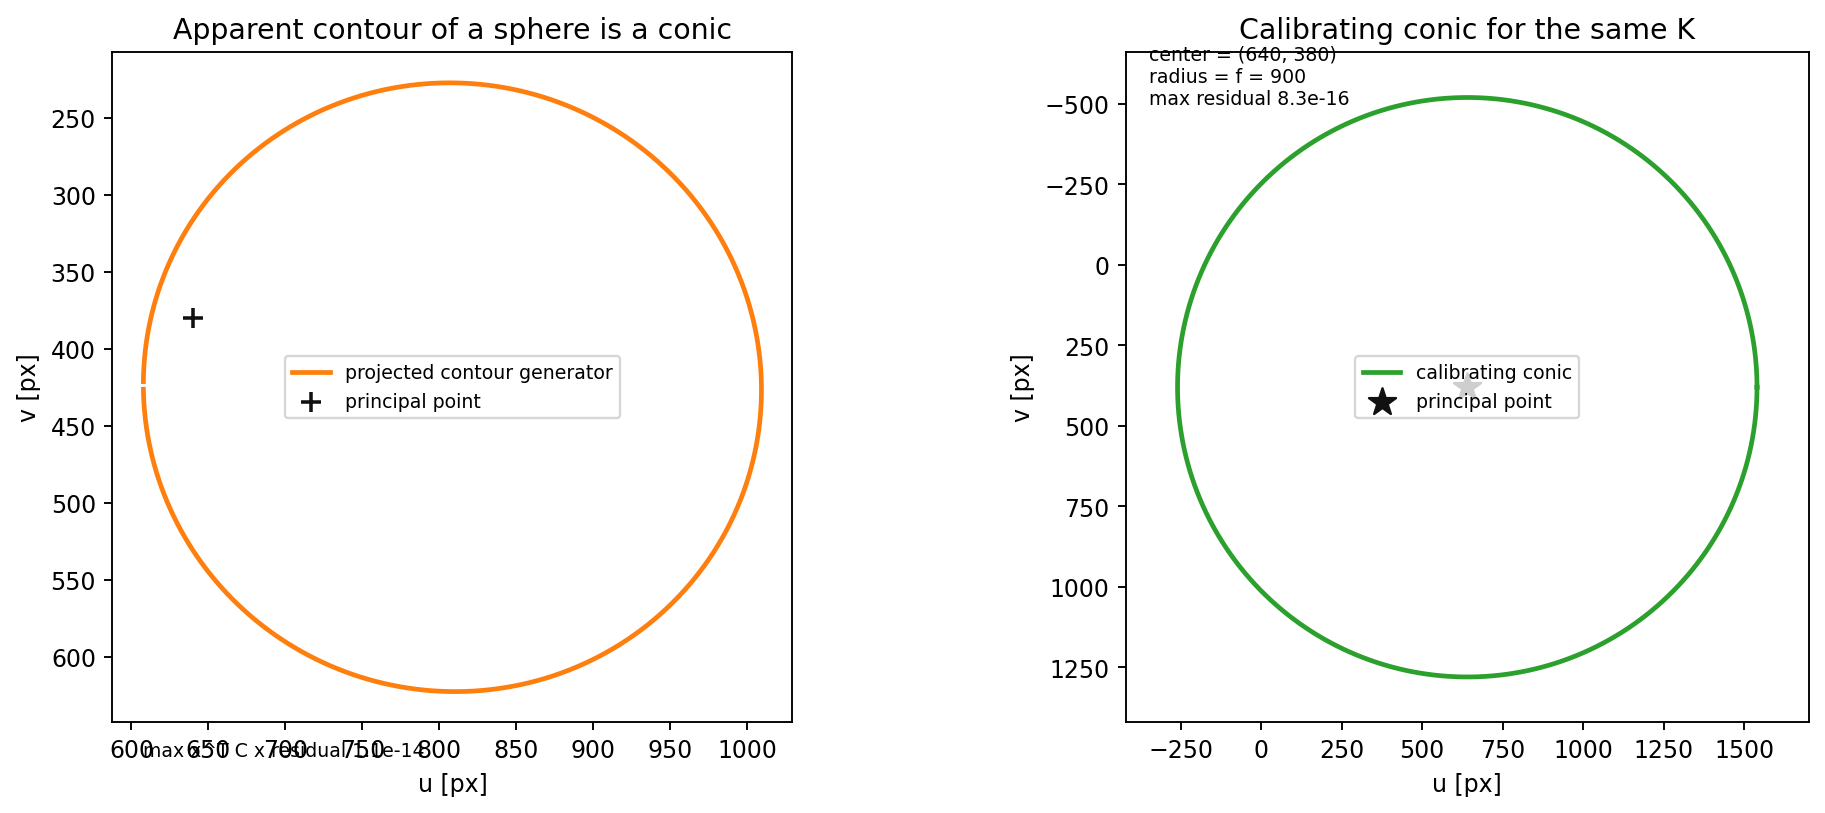

In [8]:
def sphere_quadric(center, radius):
    center = np.asarray(center, dtype=float)
    Q = np.eye(4)
    Q[:3, 3] = -center
    Q[3, :3] = -center
    Q[3, 3] = float(center @ center - radius * radius)
    return Q


def contour_generator_points_for_sphere(center, radius, n=240):
    center = np.asarray(center, dtype=float)
    norm_center = np.linalg.norm(center)
    plane_center = ((norm_center**2 - radius**2) / norm_center**2) * center
    contour_radius = radius * math.sqrt(1.0 - (radius / norm_center) ** 2)
    trial = np.array([0.0, 1.0, 0.0])
    if np.linalg.norm(np.cross(center, trial)) < 1e-8:
        trial = np.array([1.0, 0.0, 0.0])
    e1 = np.cross(center, trial)
    e1 = e1 / np.linalg.norm(e1)
    e2 = np.cross(center, e1)
    e2 = e2 / np.linalg.norm(e2)
    t = np.linspace(0.0, 2.0 * np.pi, n, endpoint=False)
    return plane_center + contour_radius * (np.cos(t)[:, None] * e1 + np.sin(t)[:, None] * e2)


sphere_center = np.array([0.75, 0.20, 4.20])
sphere_radius = 0.90
P_conic = K @ np.hstack([np.eye(3), np.zeros((3, 1))])
Q_sphere = sphere_quadric(sphere_center, sphere_radius)
Q_star_sphere = np.linalg.inv(Q_sphere)
C_star_outline = P_conic @ Q_star_sphere @ P_conic.T
C_outline = np.linalg.inv(C_star_outline)
C_outline = C_outline / np.linalg.norm(C_outline)
contour_3d = contour_generator_points_for_sphere(sphere_center, sphere_radius)
contour_xh = project_homogeneous(P_conic, np.c_[contour_3d, np.ones(len(contour_3d))])
contour_xy = dehomogeneous_rows(contour_xh)
max_projected_conic_residual = float(np.max(np.abs(np.einsum("ni,ij,nj->n", contour_xh, C_outline, contour_xh))))

D_cone = np.diag([1.0, 1.0, -1.0])
C_calibrating = np.linalg.inv(K).T @ D_cone @ np.linalg.inv(K)
cal_t = np.linspace(0.0, 2.0 * np.pi, 500)
calibrating_xy = np.c_[K[0, 2] + K[0, 0] * np.cos(cal_t), K[1, 2] + K[1, 1] * np.sin(cal_t)]
cal_xh = np.c_[calibrating_xy, np.ones(len(calibrating_xy))]
max_calibrating_residual = float(np.max(np.abs(np.einsum("ni,ij,nj->n", cal_xh, C_calibrating, cal_xh))))

phi = np.linspace(0.0, np.pi, 34)
theta_grid = np.linspace(0.0, 2.0 * np.pi, 68)
PHI, THETA = np.meshgrid(phi, theta_grid)
SX = sphere_center[0] + sphere_radius * np.sin(PHI) * np.cos(THETA)
SY = sphere_center[1] + sphere_radius * np.sin(PHI) * np.sin(THETA)
SZ = sphere_center[2] + sphere_radius * np.cos(PHI)
fig3d = go.Figure()
fig3d.add_trace(go.Surface(x=SX, y=SY, z=SZ, opacity=0.35, colorscale="Blues", showscale=False, name="sphere quadric"))
fig3d.add_trace(go.Scatter3d(x=contour_3d[:, 0], y=contour_3d[:, 1], z=contour_3d[:, 2], mode="lines", line={"color": "orange", "width": 6}, name="contour generator"))
for idx in np.linspace(0, len(contour_3d) - 1, 14, dtype=int):
    p = contour_3d[idx]
    fig3d.add_trace(go.Scatter3d(x=[0, p[0]], y=[0, p[1]], z=[0, p[2]], mode="lines", line={"color": "#666666", "width": 2}, showlegend=False))
plane_x = np.array([[-0.9, 0.9], [-0.9, 0.9]])
plane_y = np.array([[-0.55, -0.55], [0.55, 0.55]])
plane_z = np.ones_like(plane_x)
fig3d.add_trace(go.Surface(x=plane_x, y=plane_y, z=plane_z, opacity=0.18, colorscale=[[0, "#dddddd"], [1, "#dddddd"]], showscale=False, name="normalized image plane"))
fig3d.add_trace(go.Scatter3d(x=[0], y=[0], z=[0], mode="markers+text", marker={"size": 5, "color": "black"}, text=["camera center"], textposition="bottom center", name="camera center"))
fig3d.update_layout(
    title="Quadric contour generator and tangent ray cone",
    scene={"xaxis_title": "X", "yaxis_title": "Y", "zaxis_title": "Z", "aspectmode": "data"},
    margin={"l": 0, "r": 0, "b": 0, "t": 40},
)
quadric_html_path = save_plotly_html(fig3d, TOPIC, "interactive", "quadric-contour-generator-scene.html")
artifact_paths.append(quadric_html_path)
display_artifact(quadric_html_path, width=900, height=560)

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.9))
axes[0].plot(contour_xy[:, 0], contour_xy[:, 1], color="#ff7f0e", linewidth=2.0, label="projected contour generator")
axes[0].scatter([K[0, 2]], [K[1, 2]], marker="+", s=70, color="#111111", label="principal point")
axes[0].set_title("Apparent contour of a sphere is a conic")
axes[0].set_xlabel("u [px]")
axes[0].set_ylabel("v [px]")
axes[0].set_aspect("equal", adjustable="box")
axes[0].invert_yaxis()
axes[0].legend(fontsize=8)
axes[0].text(contour_xy[:, 0].min(), contour_xy[:, 1].max() + 42, f"max x^T C x residual {max_projected_conic_residual:.1e}", fontsize=8)

axes[1].plot(calibrating_xy[:, 0], calibrating_xy[:, 1], color="#2ca02c", linewidth=2.0, label="calibrating conic")
axes[1].scatter([K[0, 2]], [K[1, 2]], marker="*", s=145, color="#111111", label="principal point")
axes[1].set_xlim(-420, 1700)
axes[1].set_ylim(1420, -660)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlabel("u [px]")
axes[1].set_ylabel("v [px]")
axes[1].set_title("Calibrating conic for the same K")
axes[1].legend(fontsize=8)
axes[1].text(-350, -500, f"center = ({K[0,2]:.0f}, {K[1,2]:.0f})/nradius = f = {K[0,0]:.0f}/nmax residual {max_calibrating_residual:.1e}", fontsize=8)
fig.tight_layout()

conic_path = save_matplotlib(fig, TOPIC, "figures", "projected-quadric-and-calibrating-conic.png", dpi=170)
plt.close(fig)
artifact_paths.append(conic_path)
display_artifact(conic_path, width=920)


## Applied Lab: Noise And Degeneracy Pressure

The algebraic constraints on `omega` are linear, but that does not make the geometry insensitive. This lab perturbs the three vanishing points used for calibration and perturbs the image endpoints used for height transfer. The inspection target is not the exact error value; it is the trend. A stable configuration should degrade gradually, while near-degenerate vanishing triangles or tiny endpoint baselines would amplify noise sharply.


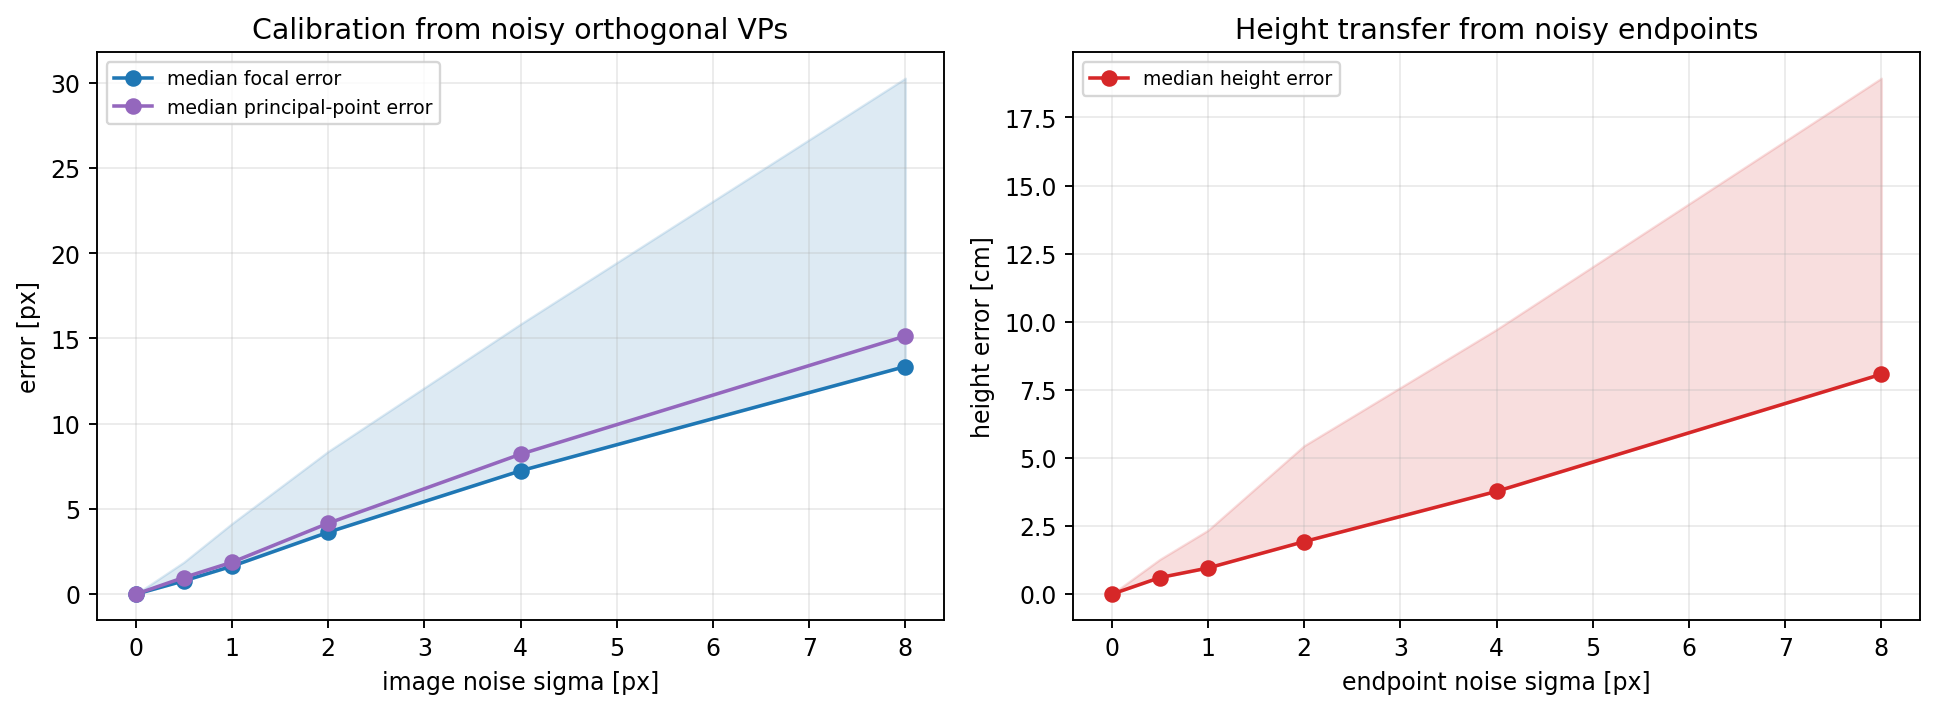

In [9]:
def noisy_square_pixel_calibration(vp_xy_samples):
    vps_h = [as_hpoint(p) for p in vp_xy_samples]
    try:
        omega_h, _ = square_pixel_omega_from_vps(vps_h)
        K_hat = square_pixel_K_from_omega(omega_h)
    except ValueError:
        return None
    return np.array([K_hat[0, 2], K_hat[1, 2], K_hat[0, 0]])


def height_ratio_from_image_points(b1p, t1p, b2p, t2p, horizon, vpoint):
    b1h, t1h, b2h, t2h = [as_hpoint(p) for p in [b1p, t1p, b2p, t2p]]
    up = normalize_finite(intersect_lines(line_from_points(b1h, b2h), horizon))
    vline2 = line_from_points(vpoint, b2h)
    transferred = normalize_finite(intersect_lines(line_from_points(t1h, up), vline2))
    c_transfer = coordinate_on_line_from_base(transferred, b2h, vpoint)
    c_t2 = coordinate_on_line_from_base(t2h, b2h, vpoint)
    c_v = coordinate_on_line_from_base(vpoint, b2h, vpoint)
    return c_transfer * (c_v - c_t2) / (c_t2 * (c_v - c_transfer))


noise_sigmas = np.array([0.0, 0.5, 1.0, 2.0, 4.0, 8.0])
trials = 180
noise_rows = []
base_height_xy = np.vstack([finite_xy(b1), finite_xy(t1), finite_xy(b2), finite_xy(t2)])
for sigma in noise_sigmas:
    f_errors = []
    pp_errors = []
    h_errors = []
    valid_calibrations = 0
    for _ in range(trials):
        noisy_vps = np.asarray(vp_xy) + rng.normal(0.0, sigma, size=(3, 2))
        params = noisy_square_pixel_calibration(noisy_vps)
        if params is not None:
            valid_calibrations += 1
            pp_errors.append(np.linalg.norm(params[:2] - K[:2, 2]))
            f_errors.append(abs(params[2] - K[0, 0]))
        noisy_height_xy = base_height_xy + rng.normal(0.0, sigma, size=base_height_xy.shape)
        ratio_noisy = height_ratio_from_image_points(noisy_height_xy[0], noisy_height_xy[1], noisy_height_xy[2], noisy_height_xy[3], ground_horizon, vvertical)
        h_errors.append(abs((height_1 / ratio_noisy) - height_2_true))
    noise_rows.append({
        "sigma_px": float(sigma),
        "valid_calibration_trials": int(valid_calibrations),
        "median_focal_error_px": float(np.median(f_errors)),
        "p90_focal_error_px": float(np.percentile(f_errors, 90)),
        "median_principal_point_error_px": float(np.median(pp_errors)),
        "p90_principal_point_error_px": float(np.percentile(pp_errors, 90)),
        "median_height_error_m": float(np.median(h_errors)),
        "p90_height_error_m": float(np.percentile(h_errors, 90)),
    })

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
axes[0].plot(noise_sigmas, [r["median_focal_error_px"] for r in noise_rows], "o-", color="#1f77b4", label="median focal error")
axes[0].plot(noise_sigmas, [r["median_principal_point_error_px"] for r in noise_rows], "o-", color="#9467bd", label="median principal-point error")
axes[0].fill_between(noise_sigmas, [r["median_focal_error_px"] for r in noise_rows], [r["p90_focal_error_px"] for r in noise_rows], color="#1f77b4", alpha=0.15)
axes[0].set_title("Calibration from noisy orthogonal VPs")
axes[0].set_xlabel("image noise sigma [px]")
axes[0].set_ylabel("error [px]")
axes[0].grid(True, alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].plot(noise_sigmas, [100.0 * r["median_height_error_m"] for r in noise_rows], "o-", color="#d62728", label="median height error")
axes[1].fill_between(noise_sigmas, [100.0 * r["median_height_error_m"] for r in noise_rows], [100.0 * r["p90_height_error_m"] for r in noise_rows], color="#d62728", alpha=0.15)
axes[1].set_title("Height transfer from noisy endpoints")
axes[1].set_xlabel("endpoint noise sigma [px]")
axes[1].set_ylabel("height error [cm]")
axes[1].grid(True, alpha=0.25)
axes[1].legend(fontsize=8)
fig.tight_layout()

noise_path = save_matplotlib(fig, TOPIC, "figures", "single-view-noise-sensitivity.png", dpi=170)
plt.close(fig)
artifact_paths.append(noise_path)
display_artifact(noise_path, width=900)


## Invariant Summary

The JSON artifact records the numeric claims made by the visuals: no-parallax under same-center rotation, vanishing-point incidence, IAC orthogonality, height-transfer accuracy, conic residuals, and the noise-lab trend. These are the values the final sanity cell asserts.


In [10]:
invariants = {
    "source_span": "Chapter 08, printed pages 195-236; PDF pages 213-254",
    "same_center_homography_residual_px": same_center_homography_residual,
    "mean_moved_center_parallax_px": mean_translation_parallax,
    "max_vanishing_line_incidence": max_vanishing_incidence,
    "horizon_incidence_sum": horizon_incidence,
    "omega_constraint_rank": int(np.linalg.matrix_rank(omega_constraint_matrix)),
    "max_iac_orthogonality_residual": max_iac_orthogonality_residual,
    "estimated_K_from_vanishing_points": K_est.round(10).tolist(),
    "principal_point_error_px": principal_point_error,
    "orthocenter_error_px": orthocenter_error,
    "focal_error_px": focal_error,
    "height_ratio_true": height_ratio_true,
    "height_ratio_estimated": float(height_ratio_est),
    "height_ratio_error": height_ratio_error,
    "height_2_true_m": height_2_true,
    "height_2_estimated_m": float(height_2_est),
    "projected_quadric_conic_residual": max_projected_conic_residual,
    "calibrating_conic_residual": max_calibrating_residual,
    "noise_lab": noise_rows,
    "artifacts": [str(p.relative_to(BOOK_ROOT)) for p in artifact_paths],
}
invariant_path = save_json(invariants, TOPIC, "checks", "single-view-geometry-invariants.json")
artifact_paths.append(invariant_path)
display_artifact(invariant_path)
print(json.dumps({k: invariants[k] for k in [
    "same_center_homography_residual_px",
    "mean_moved_center_parallax_px",
    "max_vanishing_line_incidence",
    "principal_point_error_px",
    "height_ratio_error",
    "projected_quadric_conic_residual",
]}, indent=2))


`artifacts/chapter-08/checks/single-view-geometry-invariants.json`

{
  "same_center_homography_residual_px": 2.2737367544323206e-13,
  "mean_moved_center_parallax_px": 85.7121405290527,
  "max_vanishing_line_incidence": 6.575367479499384e-16,
  "principal_point_error_px": 8.526512829121202e-13,
  "height_ratio_error": 2.220446049250313e-16,
  "projected_quadric_conic_residual": 1.0658141036401503e-14
}


## Final Sanity Checks

The checks below are deliberately geometric: homographies must map same-center views, projected parallel lines must hit their vanishing points, the IAC must encode orthogonality, height transfer must recover the synthetic ratio, projected contour samples must satisfy the conic equation, and all artifacts must exist with nonzero size.


In [11]:
assert_artifacts(artifact_paths, min_bytes=256)
assert same_center_homography_residual < 1e-9
assert mean_translation_parallax > 25.0
assert max_vanishing_incidence < 1e-10
assert horizon_incidence < 1e-8
assert np.linalg.matrix_rank(omega_constraint_matrix) == 3
assert max_iac_orthogonality_residual < 1e-12
assert principal_point_error < 1e-6
assert orthocenter_error < 1e-6
assert focal_error < 1e-6
assert height_ratio_error < 1e-10
assert abs(height_2_est - height_2_true) < 1e-10
assert max_projected_conic_residual < 1e-10
assert max_calibrating_residual < 1e-12
assert noise_rows[-1]["median_focal_error_px"] > noise_rows[1]["median_focal_error_px"]
assert noise_rows[-1]["median_height_error_m"] > noise_rows[1]["median_height_error_m"]

legacy_name_parts = [("concept", "map", "png"), ("geometry", "scene", "png"), ("diagnostic", "dashboard", "png"), ("constraint", "dashboard", "png"), ("numeric", "summary", "json")]
for prefix, stem, suffix in legacy_name_parts:
    legacy_name = f"{prefix}-{stem}.{suffix}"
    assert all(path.name != legacy_name for path in artifact_paths)

final_sanity = {
    "artifact_count": len(artifact_paths),
    "chapter_specific_artifacts": [str(path.relative_to(BOOK_ROOT)) for path in artifact_paths],
    "same_center_homography_residual_px": same_center_homography_residual,
    "height_2_estimated_m": height_2_est,
    "max_projected_conic_residual": max_projected_conic_residual,
}
print(json.dumps(final_sanity, indent=2))


{
  "artifact_count": 8,
  "chapter_specific_artifacts": [
    "artifacts//chapter-08//figures//same-center-homography-vs-parallax.png",
    "artifacts//chapter-08//figures//manhattan-vanishing-points-and-horizon.png",
    "artifacts//chapter-08//figures//iac-orthogonal-triad-calibrating-conic.png",
    "artifacts//chapter-08//figures//height-transfer-affine-measurement.png",
    "artifacts//chapter-08//interactive//quadric-contour-generator-scene.html",
    "artifacts//chapter-08//figures//projected-quadric-and-calibrating-conic.png",
    "artifacts//chapter-08//figures//single-view-noise-sensitivity.png",
    "artifacts//chapter-08//checks//single-view-geometry-invariants.json"
  ],
  "same_center_homography_residual_px": 2.2737367544323206e-13,
  "height_2_estimated_m": 1.2500000000000002,
  "max_projected_conic_residual": 1.0658141036401503e-14
}


## Takeaways

- A fixed camera center turns image changes into homographies and preserves ray coincidences; moving the center introduces parallax.
- Vanishing points are images of directions, and a plane's vanishing line is the image of its line at infinity.
- The IAC is the calibration matrix in conic form: it converts image-point algebra into ray-angle algebra.
- Orthogonal vanishing directions give linear constraints on `omega`; with square pixels, three orthogonal vanishing points recover the principal point and focal length in this synthetic scene.
- Single-view height measurement is a projective construction: transfer a known height, then send the direction's vanishing point to infinity before reading an affine ratio.
- Quadric outlines are conics because tangent image lines pull back to tangent planes, and the calibrating conic gives a real visualization of the same internal calibration that the IAC stores algebraically.
